In [1]:
import sys
#sys.path.append('../../../../Fixed_Voltage_OpenMM/lib/')
from MDAnalysis import *
import numpy as np
import argparse
import math
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [2]:
# get Voltage from command line input
parser = argparse.ArgumentParser()
parser.add_argument("voltage", type=str, help="voltage of simulation")
args, unknown = parser.parse_known_args() # 忽略未知參數
#Vapp = float(args.voltage) 因為Jupyter_notebook本身的問題導致無法正常運作
Vapp = float(input("請輸入電壓(浮點數):"))
pdb_file=r"/home/atuo/Simulation/OpenMM-ConstantV/test_3cnt/Poisson/start_equilibrated.pdb" #去跑看看自己的電荷密度檔案是 否可行
# this file should contain charge density in e/Ang^3
electrolyte_charge_file = r"/home/atuo/Simulation/OpenMM-ConstantV/test_3cnt/Poisson/electrolyte_charge_density.xvg" #選擇包含陰陽離子的solution檔案
electrode_charge_file = r"/home/atuo/Simulation/OpenMM-ConstantV/test_3cnt/Poisson/electrode_charge.xvg" #選擇當時跑完模擬所需的總陰離子電荷輸出檔

# conversions
ang2bohr = 1.88973
eV2hartree = 0.0367
pi = 3.1415926535
conv = 1/(ang2bohr**3)

# get average electrode charge
electrode_charges=[]
with open( electrode_charge_file ) as f:
    for line in f:
        electrode_charges.append( float( line ) )
avg_electrode_charge = np.average( electrode_charges )
print( "average electrode charge:", avg_electrode_charge )

# import pdb file to get Lcell, Lgap, surface Area
u=Universe(pdb_file,pdb_file)
atoms=u.select_atoms('resname grpc') # should pull both virtual cathode/anode graphene
# get bounds of electrochemical cell
z_left = atoms[0].position[2] ; z_right = atoms[800].position[2]  # 800 atoms per sheet
Lcell = z_right - z_left
# get length of vacuum gap
Lgap = u.trajectory[0].triclinic_dimensions[2][2] - Lcell
# get area of electrode
surfaceArea = np.linalg.norm( np.cross( u.trajectory[0].triclinic_dimensions[0] , u.trajectory[0].triclinic_dimensions[1] ) )
print( f"Voltage: {Vapp}, \nLcell: {Lcell}, \nLgap: {Lgap}, \nArea: {surfaceArea}" )

請輸入電壓(浮點數): 5


average electrode charge: -17.39983490341095
Voltage: 5.0, 
Lcell: 87.40799713134766, 
Lgap: 93.01399993896484, 
Area: 2103.158447265625


# 有可能是因為下方程式並未正確抓到資料，導致後面的作圖錯誤

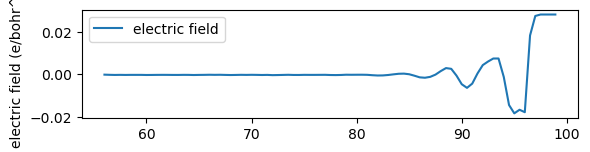

In [4]:
#******* read in electrolyte charge density **********
ifile = open(electrolyte_charge_file)
bins=100        # get this from charge_density file
lines = ifile.readlines()
ifile.close()

# bin width
dz = float(lines[1].split()[0]) - float(lines[0].split()[0])

z_dist= []
q_avg = []

#***** data may be collected outside electrochemical cell, only store points inside cell
for i in range(len(lines)):
    z = float(lines[i].split()[0])
    if z > z_left and z < z_right:
        z_dist.append( z )
        # charge density in e/Ang^3
        q_avg.append( float(lines[i].split()[1]) )

#print(sum(q_avg))

# ********** Assuming "flat electrode" is on right **************
# reverse arrays, because we want to integrate from right to left
z_dist = np.flip( z_dist )
q_avg = np.flip( q_avg )


#********** Now integrate to get Poisson profile **********
surfQ = avg_electrode_charge
E_surface = 4*pi *surfQ/((surfaceArea)*(ang2bohr**2))
E_gap = -(Vapp*eV2hartree/(Lgap*ang2bohr))
E_z=[] ; z1_dist=[]

# old code for integrating L to R ...
#E_i = E_surface + E_gap
# new code for integrating R to L ...
E_i = E_gap - E_surface

# append initial efield
z1_dist.append( z_right ) 
#E_z.append( E_i )

# only compute to halfway through the cell, as integration out to CNT electrode is unphysical (no x/y symmetry)
max_length = int(len(q_avg) / 2)

# the first integration point is z_right to z_dist[0], this may not equal dz so do this before loop
E_i = E_i - 4*pi*q_avg[0]*conv*abs(z_dist[0] - z_right)*ang2bohr
E_z.append(E_i)
z1_dist.append( z_dist[0] )

for z_i in range(1,max_length):
    # old code for integration L to R ...
    #E_i = E_i + 4*pi*q_avg[z_i]*conv*dz*ang2bohr
    # new code for integrating R to L ...
    E_i = E_i - 4*pi*q_avg[z_i]*conv*dz*ang2bohr
    E_z.append(E_i)
    z1_dist.append( z_dist[z_i] )

plt.subplot(312)
plt.ylabel("electric field (e/bohr^2)")
plt.plot(z1_dist[:-1],E_z)
plt.legend(['electric field'], loc='best')
plt.savefig('efield_Poisson.png')

Vanode , Vbulk , delta_V 
-2.5 -0.07979784535375758 2.420202154646242


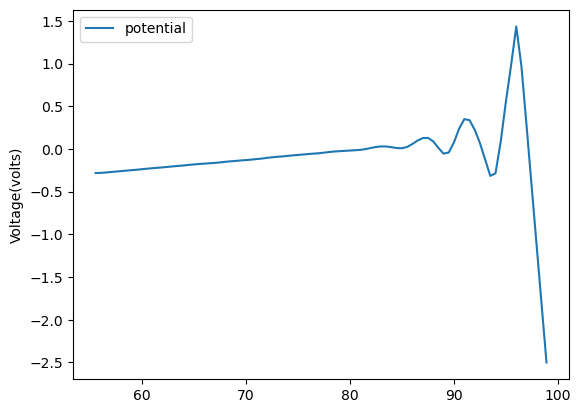

In [5]:
# calculate voltage in a.u., store in volts
V_z=[]
# assume right electrode is at - Vapp / 2
V_i =  - Vapp/2.0 * eV2hartree
V_z.append(-Vapp/2.0)  # store in volts

# the first integration point is z_right to z_dist[0], this may not equal dz so do this before loop
V_i = V_i + E_z[0]*abs(z_dist[0] - z_right)*ang2bohr
# store in volts
V_z.append(V_i/eV2hartree)

for z_i in range(1,max_length):
    # old code for integration L to R
    #V_i = V_i - E_z[z_i]*dz*ang2bohr
    # new code for integration R to L
    V_i = V_i + E_z[z_i]*dz*ang2bohr
    # store in volts
    V_z.append(V_i/eV2hartree)

# append the last point
#z1_dist.append( z1_dist[ len(z1_dist) -1 ] - dz )

# compute bulk Voltage by averaging v_z[40:60].  
# Note this is 2nm from the electrode, which is sufficient for double layer to decay to bulk
# we don't want to go farther than this because we might hit other electrode for say the 3CNT system...
V_bulk = np.mean(V_z[40:60])
print( "Vanode , Vbulk , delta_V " )
print( -Vapp/2.0 , V_bulk , ( V_bulk + Vapp/2.0 ) )

#plt.subplot(313)
plt.ylabel("Voltage(volts)")
plt.plot(z1_dist,V_z)
plt.legend(['potential'], loc='best')
plt.savefig('Voltage_Poisson.png')
